# Task 0: Setting up Ollama (1p)a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.

b) Load the 270m parameter version of the gemma3 model and test it with any prompt.

c) Load the 4b parameter version of the gemma3 and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [33]:
# a)
import ollama
from ollama import chat

# b)
response = ollama.chat(
    model="gemma3:270m",
    messages=[
        {"role": "user", "content": "Hello"}
    ]
)
print(response["message"]["content"])
# c) 
response = ollama.chat(
    model="gemma3:4b",
    messages=[
    {"role": "user", "content": "Explain what machine learning is in one sentence"}
    ]
)

print(response["message"]["content"])

Hello! How can I help you today?

Machine learning is a field of computer science where algorithms learn from data without explicit programming, enabling them to make predictions or decisions about new data.


# Task 1: Text classification with Ollama (2p)
The data/emails.csv file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [3]:
# a)
import pandas as pd

emails = pd.read_csv("Data/emails.csv", sep=";")
emails.head()

import ollama

def classify_email(headline, model_name):
    prompt=f"""
    Classify the following email headline into one of these categories:
    - spam
    - work
    - unknown
    
    Return ONLY the category name.
    
    Headline: {headline}
    """

    response = ollama.chat(
        model=model_name,
        messages=[
            {"role": "user", "content": prompt}
            
        ]
    )

    return response["message"]["content"].strip().lower()

In [5]:
# b)
emails["gemma3_270m"]=emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:270m")
)

emails

,headline,gemma3_270m
0,URGENT: Your account will be suspended within ...,suspended
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,work
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,**work**
5,"Q3 budget report attached, please review by Fr...",
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",
8,Quick question about last week,spam
9,Following up,


In [7]:
# c)
emails["gemma3_4b"]=emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:4b")
)

emails

,headline,gemma3_270m,gemma3_4b
0,URGENT: Your account will be suspended within ...,suspended,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,work,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam
4,Meeting agenda for Thursday's project review,**work**,work
5,"Q3 budget report attached, please review by Fr...",,work
6,Reminder: Annual performance review scheduled ...,work,work
7,"Updated draft of the manuscript, comments welcome",,work
8,Quick question about last week,spam,unknown
9,Following up,,unknown


In [9]:
# d)
results_270m = pd.DataFrame()
results_4b = pd.DataFrame()

results_270m["headline"] = emails["headline"]
results_4b["headline"] = emails["headline"]

for i in range(3):
    results_270m[f"run_{i+1}"] = emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:270m")
    )

    results_4b[f"run_{i+1}"] = emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:4b")
    )

print("270m Results")
display(results_270m)

print("4b Results")
display(results_4b)

270m Results


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,suspended,suspended,suspended
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,work,work,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,work
4,Meeting agenda for Thursday's project review,work,**work**,spam
5,"Q3 budget report attached, please review by Fr...",,spam,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",spam,,
8,Quick question about last week,unknown,spam,spam
9,Following up,,,


4b Results


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,work,unknown,unknown


# Task 2: Sentiment analysis with Ollama (2p)
The data/news.csv file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [1]:
# a)
import pandas as pd
news = pd.read_csv("Data/news.csv", sep=";")
news.head()

import json
import ollama
def classify_news(headline, model_name="gemma3:4b"):
    prompt = f"""
    Classify the following financial news headline.
    
    Topic options:
    - earnings
    - mergers 
    - regulation
    - macroeconomics
    
    Sentiment options:
    - positive
    - negative
    - neutral
    
    Return ONLY valid JSON.

    Example:
    {{
        "topic": "...",
        "sentiment": "..."
    }}
    
    Headline: {headline}
    """

    response = ollama.chat(
        model=model_name,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    content = response["message"]["content"]

    if not isinstance(content,str):
        content=str(content)
    
    content = content.replace("```json", "").replace("```","")
    content = content.strip()

    return json.loads(content)

In [5]:
# b)
results = news.copy()

classified = results["headline"].apply(classify_news)

results["topic"] = classified.apply(lambda x: x["topic"])
results["sentiment"] = classified.apply(lambda x: x["sentiment"])

results

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


# c)
Browser LLM Results:

| Headline | Topic | Sentiment |
|---|---|---|
| Company profits rise | earnings | positive |
| Central bank raises rates | macroeconomics | negative |
| ... | ... | ... |

Comparison:

The browser-based LLM generally produced more accurate and nuanced classifications than the local Gemma3 model.
This is likely because commercial browser LLMs are significantly larger and trained on more diverse datasets.

However, Gemma3 still performed reasonably well and has the advantage of running locally without requiring internet access.

# Task 3: Supervised machine learning (5p)
For this task, use a subset of the Bank Marketing dataset, by downloading and importing the bank-additional.csv from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

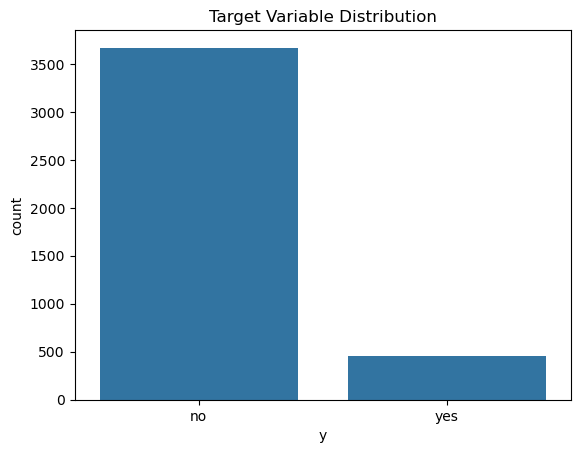

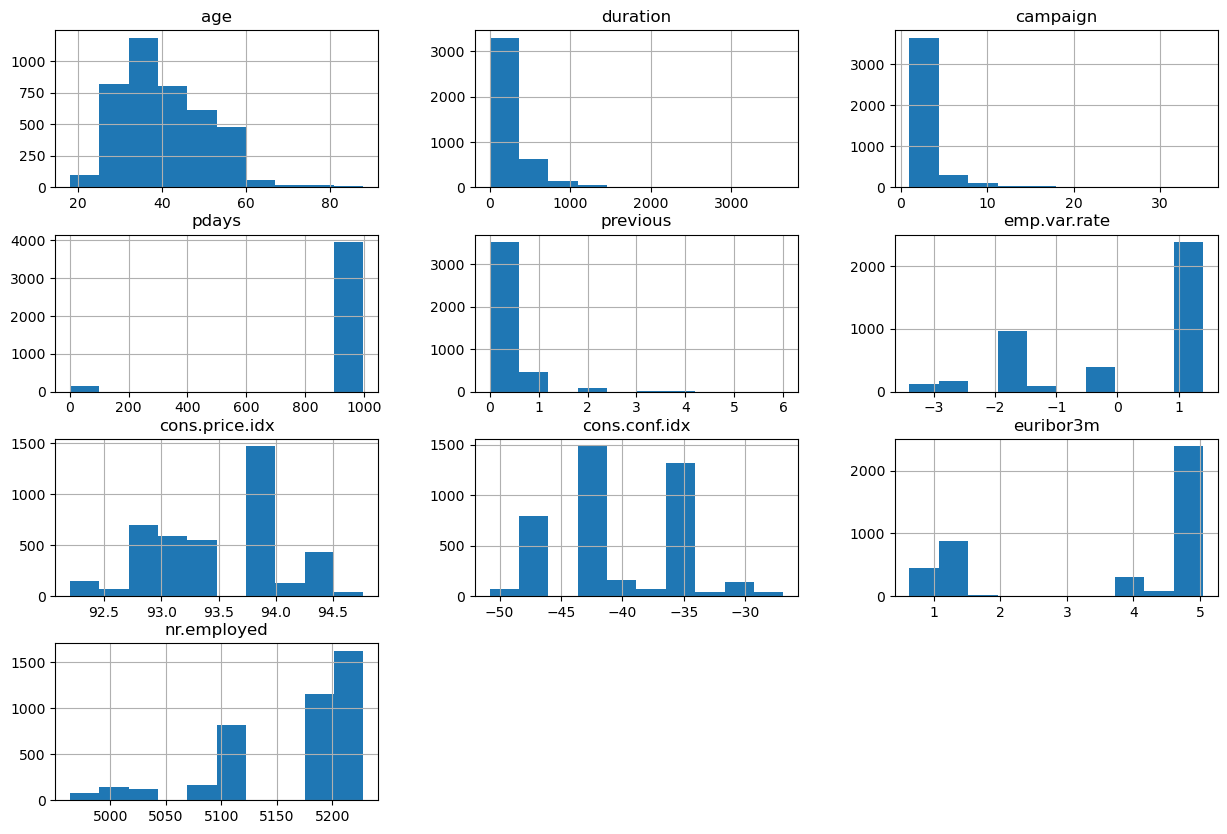

In [5]:
# a)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

import pandas as pd

bank = pd.read_csv(
    "bank-additional.csv",
    sep=";"
)

bank.head()

bank.info()

bank.describe()

bank.isnull().sum()

bank["y"].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="y", data=bank)
plt.title("Target Variable Distribution")
plt.show()

bank.hist(figsize=(15,10))
plt.show()

In [6]:
# b)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = bank.drop("y", axis=1)
y = bank["y"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

print(accuracy_score(y_test, rf_preds))

0.9053398058252428


In [11]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_preds = gb_pipeline.predict(X_test)

print(accuracy_score(y_test, gb_preds))

0.9174757281553398


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

scoring = make_scorer(f1_score, average="binary")

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10]
}

search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro"
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'classifier__max_depth': 10, 'classifier__n_estimators': 100}
0.6841622387265061


In [17]:
# c)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

logreg_preds = logreg_pipeline.predict(X_test)

print(accuracy_score(y_test, logreg_preds))

0.9211165048543689


In [19]:
# d)
from sklearn.model_selection import train_test_split

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

rf_pipeline.fit(X_train2, y_train2)
y_pred = rf_pipeline.predict(X_val)

val_score = f1_score(y_val, y_pred, average="macro")
print("Validation F1 score:", val_score)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("CV scores:", scores)
print("Mean CV scores:", scores.mean())

print("Comparison:")
print("Validation score:", val_score)
print("Cross-validation mean score:", scores.mean())

if scores.mean() > val_score:
    print("Cross-validation performs better.")
else:
    print("Train/validation split performs better.")

Validation F1 score: 0.6629500818330605
CV scores: [0.67243505 0.63487316 0.70560618 0.66118421 0.69097828]
Mean CV scores: 0.6730153768408966
Comparison:
Validation score: 0.6629500818330605
Cross-validation mean score: 0.6730153768408966
Cross-validation performs better.


# d)
Cross-validation produced more reliable performance estimates because the model was trained and evaluated on multiple folds.

The train/validation/test split is faster but may depend heavily on the specific random split.

Cross-validation generally performed better